# Ultimate Technologies Inc Take-Home Challenge
### By Brad Wicklund

## 1.0 Exploritory Data Analysis

### 1.1 Setup Notebook

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Load data
logins = pd.read_json("../data/raw/logins.json")
df = pd.read_json("../data/raw/ultimate_data_challenge.json")

### 1.2 Data Overview

In [4]:
# Examine data
logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [5]:
logins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


In [6]:
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


In [14]:
# Convert signup_date and last_trip_date to datetime
df['signup_date'] = pd.to_datetime(df['signup_date'], format = '%Y-%m-%d')
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'], format = '%Y-%m-%d')

df.dtypes

city                              object
trips_in_first_30_days             int64
signup_date               datetime64[ns]
avg_rating_of_driver             float64
avg_surge                        float64
last_trip_date            datetime64[ns]
phone                             object
surge_pct                        float64
ultimate_black_user                 bool
weekday_pct                      float64
avg_dist                         float64
avg_rating_by_driver             float64
dtype: object

### 1.3 Login Data Quality Check and Validation

In [17]:
# Check logins shape
logins.shape

(93142, 1)

In [19]:
# Min / Max timestamps
print("Min timestamp:", logins['login_time'].min())
print("Max timestamp:", logins['login_time'].max())

Min timestamp: 1970-01-01 20:12:16
Max timestamp: 1970-04-13 18:57:38


In [21]:
# Check for missing values
print(logins.isna().sum())

login_time    0
dtype: int64


### 1.4 Aggregate Logins

In [24]:
# Set index
logins = logins.set_index('login_time').sort_index()

In [26]:
# Resample into 15 min buckets
logins_15 = logins.resample('15min').size()

In [28]:
# Inspect bucket size
print(logins_15.head(20))

login_time
1970-01-01 20:00:00     2
1970-01-01 20:15:00     6
1970-01-01 20:30:00     9
1970-01-01 20:45:00     7
1970-01-01 21:00:00     1
1970-01-01 21:15:00     4
1970-01-01 21:30:00     0
1970-01-01 21:45:00     4
1970-01-01 22:00:00     9
1970-01-01 22:15:00     8
1970-01-01 22:30:00     1
1970-01-01 22:45:00     3
1970-01-01 23:00:00    16
1970-01-01 23:15:00    13
1970-01-01 23:30:00    14
1970-01-01 23:45:00    15
1970-01-02 00:00:00    10
1970-01-02 00:15:00    18
1970-01-02 00:30:00    12
1970-01-02 00:45:00    13
Freq: 15min, dtype: int64


### 1.5 Plot Aggregated Login Data

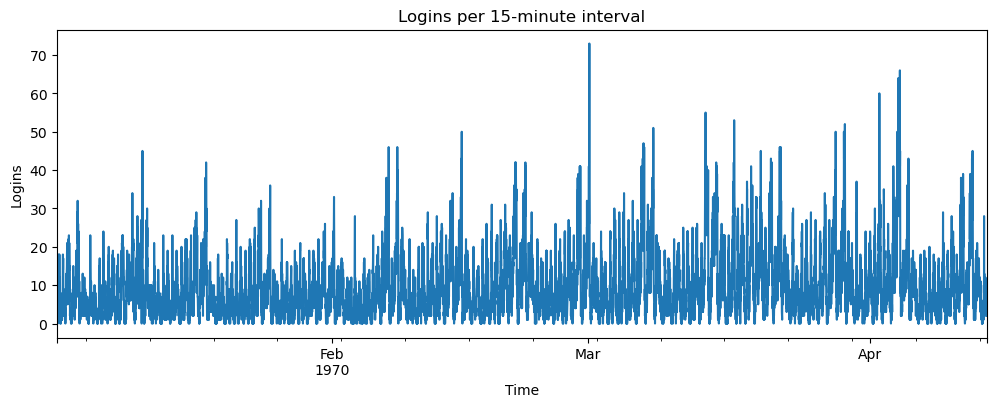

In [31]:
# Plot aggregated login data
plt.figure(figsize=(12,4))
logins_15.plot()
plt.title("Logins per 15-minute interval")
plt.xlabel("Time")
plt.ylabel("Logins")
plt.show()

In [32]:
# Index logins by hour
logins_15 = logins_15.to_frame(name="count")
logins_15['hour'] = logins_15.index.hour

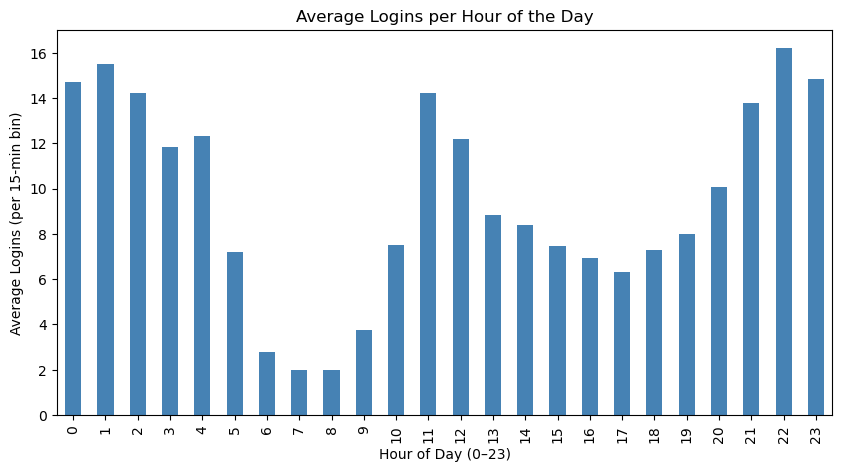

In [33]:
# Group by hour of the day and average across all days
avg_per_hour = logins_15.groupby('hour')['count'].mean()

# Plot
plt.figure(figsize=(10,5))
avg_per_hour.plot(kind='bar', color='steelblue')
plt.title("Average Logins per Hour of the Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Logins (per 15-min bin)")
plt.xticks(range(24), range(24))
plt.show()

In [34]:
# Index by day of the week
logins_15['dayofweek'] = logins_15.index.dayofweek
logins_15['dayname'] = logins_15.index.day_name() 

In [35]:
# Average logins per day of week
avg_per_day = logins_15.groupby('dayname')['count'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

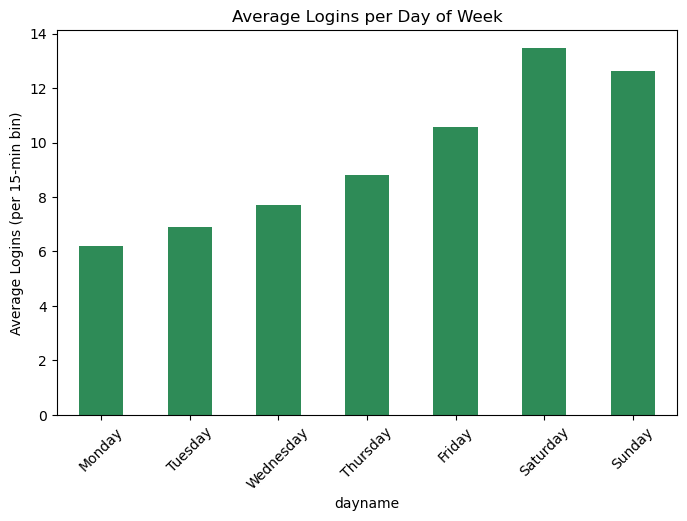

In [36]:
# Plot
plt.figure(figsize=(8,5))
avg_per_day.plot(kind='bar', color='seagreen')
plt.title("Average Logins per Day of Week")
plt.ylabel("Average Logins (per 15-min bin)")
plt.xticks(rotation=45)
plt.show()

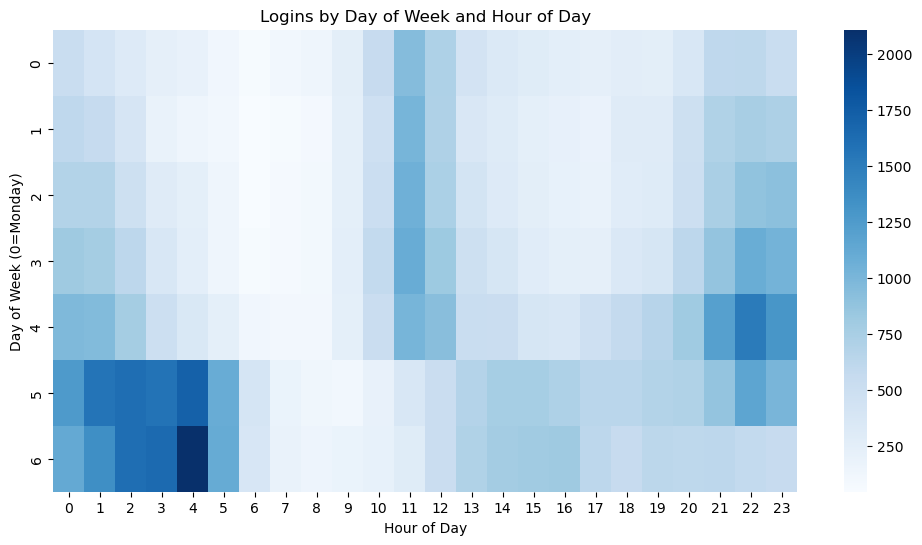

In [37]:
# Reset index
logins = logins.reset_index()

# Create hour column
logins['hour'] = logins['login_time'].dt.hour   

# Count number of logins days and hours
logins['day_of_week'] = logins['login_time'].dt.dayofweek
login_counts = logins.groupby(['day_of_week', 'hour']).size().reset_index(name='count')

# Pivot data so days are rows and hours are columns
heatmap_data = login_counts.pivot(index='day_of_week', columns='hour', values='count')

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="Blues", annot=False)

plt.title("Logins by Day of Week and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Monday)")
plt.show()

### 1.6 Exploratory Data Analysis Summary
After resampling the login data into 15-minute intervals, clear daily and weekly patterns appear. Logins are lowest during the early morning hours (around 4–7 AM) and increase throughout the day, with noticeable peaks in the late evening and at night. When looking across the week, weekdays show steady activity, but weekends stand out: Friday and Saturday nights have very strong spikes in logins, especially around 2–4 AM, while Sunday activity tapers off earlier. This suggests that user behavior follows both a daily cycle (sleep and active hours) and a weekly cycle (weekend nightlife). The data did not show major missing intervals or irregularities, so it can be considered reliable for further analysis.

## 2.0 Experiment and Metrics Design

### 2.1 Define Success Metrics

The goal of the experiment is to encourage drivers to operate in both Gotham and Metropolis by reimburseming tolls.
   - **Proposed Metric:** % of active drivers who complete trips in both cities within a given time window.
   - **Why?:** This directly measures whether the toll reimbursement reduces city exclusivity.

### 2.2 Describe Practical Experiment

**Unit of analysis:** Driver partners

**Randomization:** Split drivers into treatment (toll reimbursement) and control (no reimbursement) groups. Random assignment ensures fair comparison.

**Implementation:**
   - Treatment drivers get reimbursed for tolls automatically.
   - Control drivers continue under current conditions.
   - Run experiment for 4–6 weeks to capture weekday and weekend cycles.

**Statistical Testing:**
   - **Primary test:** Two-proportion z-test to compare the fraction of drivers who drive in both cities (treatment vs. control).
   - **Supporting test:** t-test or Mann-Whitney U for average trips per driver across groups.

**Assumptions:**
  - Random assignment creates balance between groups.
  - Enough sample size for reliable inference.

**Interpreting Results:**
  - If treatment drivers show a statistically significant increase in cross-city activity we recommend rolling out toll reimbursement.
  - If effect is weak or not significant we should consider alternative incentives.

**Caveats:**
  - Seasonal effects might affect demand.
  - Long-term behavior could differ from short-term experiment.
  - Drivers may “game” the system.

## 3.0 Predictive Modeling

### 3.1 Data Cleaning

In [53]:
# Data already loaded at beginning of notebook as 'df'

# Parsing dates
for col in ["signup_date", "last_trip_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format="%Y%m%d", errors="coerce")

In [55]:
# Define retention
snapshot_date = df["last_trip_date"].max()
lookback = pd.Timedelta(days=30)

df["retained"] = (df["last_trip_date"] >= (snapshot_date - lookback))

# Users with no trips are not retained
df.loc[df["last_trip_date"].isna(), "retained"] = False
df["retained"] = df["retained"].astype(bool)

# Data validation
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)

print("\nMissing values (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20))

Shape: (50000, 13)

Dtypes:
city                              object
trips_in_first_30_days             int64
signup_date               datetime64[ns]
avg_rating_of_driver             float64
avg_surge                        float64
last_trip_date            datetime64[ns]
phone                             object
surge_pct                        float64
ultimate_black_user                 bool
weekday_pct                      float64
avg_dist                         float64
avg_rating_by_driver             float64
retained                            bool
dtype: object

Missing values (top 20):
avg_rating_of_driver      8122
phone                      396
avg_rating_by_driver       201
city                         0
trips_in_first_30_days       0
signup_date                  0
avg_surge                    0
last_trip_date               0
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
retained                   

### 3.2 Quick EDA

In [58]:
# Numeric summary for continous features
numeric_cols = [
    c for c in ["avg_dist","avg_rating_by_driver","avg_rating_of_driver",
                "surge_pct","avg_surge","trips_in_first_30_days","weekday_pct"]
    if c in df.columns
]
print("\nNumeric describe:")
print(df[numeric_cols].describe().T)


Numeric describe:
                          count       mean        std  min    25%    50%  \
avg_dist                50000.0   5.796827   5.707357  0.0   2.42   3.88   
avg_rating_by_driver    49799.0   4.778158   0.446652  1.0   4.70   5.00   
avg_rating_of_driver    41878.0   4.601559   0.617338  1.0   4.30   4.90   
surge_pct               50000.0   8.849536  19.958811  0.0   0.00   0.00   
avg_surge               50000.0   1.074764   0.222336  1.0   1.00   1.00   
trips_in_first_30_days  50000.0   2.278200   3.792684  0.0   0.00   1.00   
weekday_pct             50000.0  60.926084  37.081503  0.0  33.30  66.70   

                           75%     max  
avg_dist                  6.94  160.96  
avg_rating_by_driver      5.00    5.00  
avg_rating_of_driver      5.00    5.00  
surge_pct                 8.60  100.00  
avg_surge                 1.05    8.00  
trips_in_first_30_days    3.00  125.00  
weekday_pct             100.00  100.00  


In [60]:
# Check categorical features
for col in [c for c in ["city","phone","ultimate_black_user"] if c in df.columns]:
    print(f"\nValue counts: {col}")
    print(df[col].value_counts(dropna=False).head(10))


Value counts: city
city
Winterfell        23336
Astapor           16534
King's Landing    10130
Name: count, dtype: int64

Value counts: phone
phone
iPhone     34582
Android    15022
None         396
Name: count, dtype: int64

Value counts: ultimate_black_user
ultimate_black_user
False    31146
True     18854
Name: count, dtype: int64


In [62]:
# Retention fraction
retained_fraction = df["retained"].mean()
n_users = len(df)
n_retained = df["retained"].sum()
print(f"\nRetention: {n_retained}/{n_users} = {retained_fraction:.3%}")


Retention: 18804/50000 = 37.608%


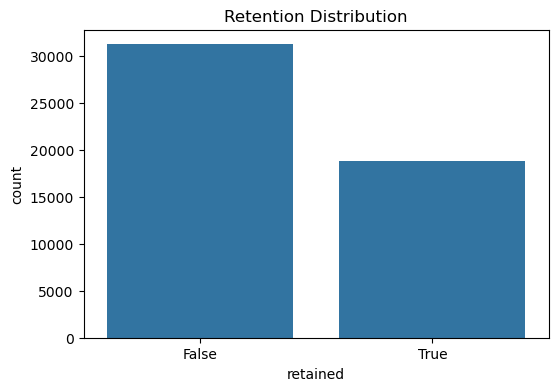

In [64]:
# Retention distribution
plt.figure(figsize=(6,4))
sns.countplot(x="retained", data=df)
plt.title("Retention Distribution")
plt.show()

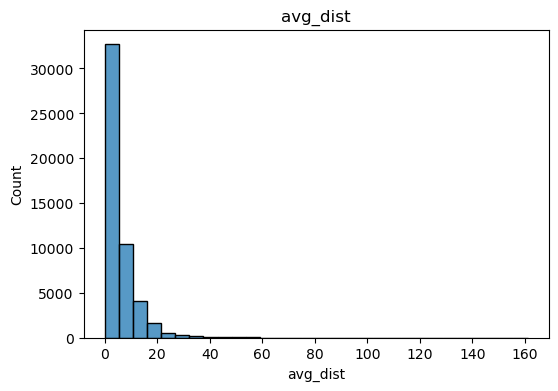

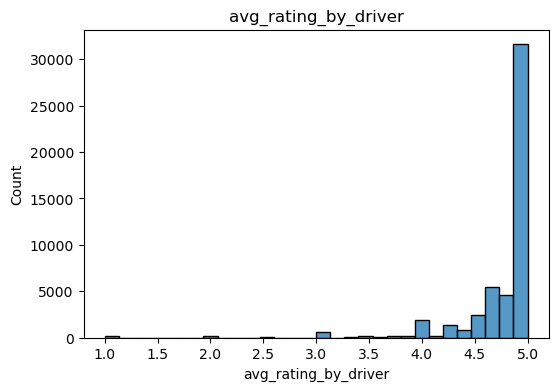

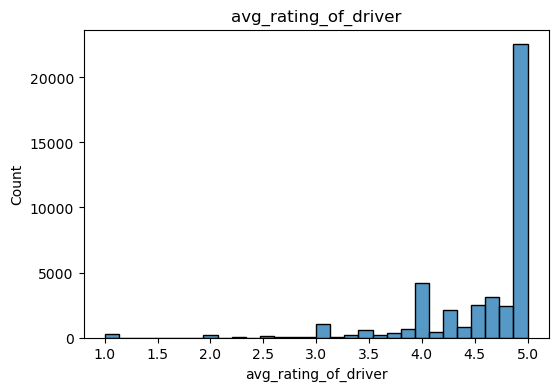

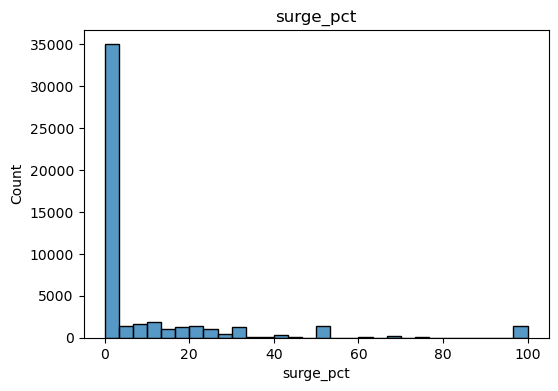

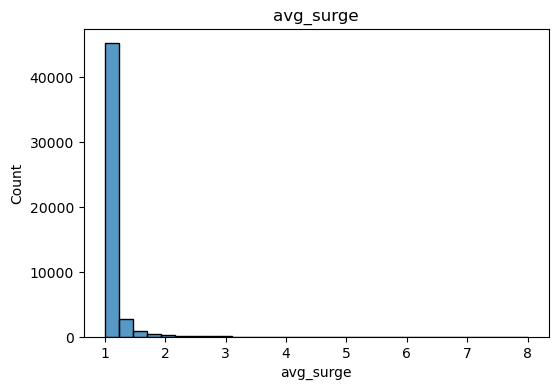

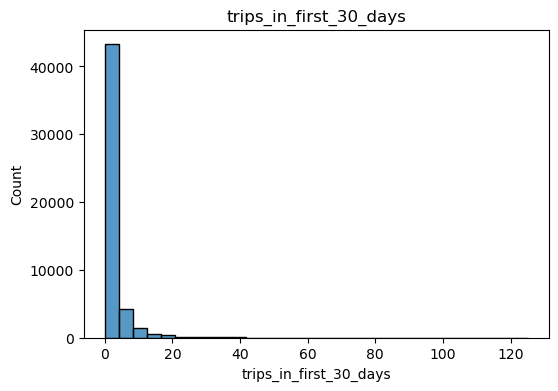

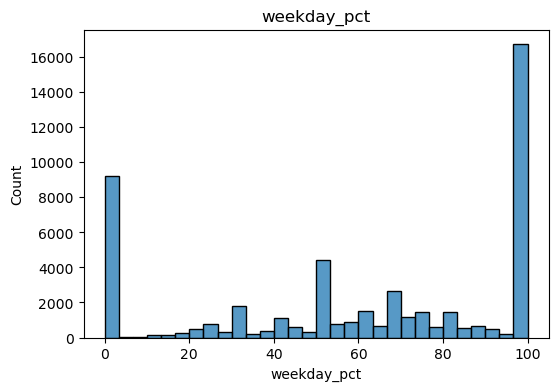

In [66]:
# Histograms for key numeric features
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(col)
    plt.show()

In [67]:
# Ratings missingness check by retention
if "avg_rating_by_driver" in df.columns:
    by_ret = df.groupby("retained")["avg_rating_by_driver"].apply(lambda s: s.isna().mean())
    print("\nMissing avg_rating_by_driver by retained:")
    print(by_ret)


Missing avg_rating_by_driver by retained:
retained
False    0.005289
True     0.001914
Name: avg_rating_by_driver, dtype: float64


In [70]:
# City/phone split by retention
for col in [c for c in ["city","phone"] if c in df.columns]:
    ct = pd.crosstab(df[col], df["retained"], normalize="index").round(3)
    print(f"\nRetention by {col}:")
    print(ct)


Retention by city:
retained        False  True 
city                        
Astapor         0.744  0.256
King's Landing  0.372  0.628
Winterfell      0.648  0.352

Retention by phone:
retained  False  True 
phone                 
Android   0.791  0.209
iPhone    0.551  0.449


**Retention Results**

Out of 50,000 users, 18,804 (37.6%) were retained. Retention was higher in King’s Landing and among iPhone users, suggesting location and device are important predictors.

### 3.3 Build Predictive Model

In [74]:
# Import libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [76]:
# Feature engineering
# Feature: account age (days)
df["account_age_days"] = (df["last_trip_date"].max() - df["signup_date"]).dt.days

In [78]:
# Impute missing values
df = df.copy()

df = df.fillna({
    "avg_rating_of_driver": df["avg_rating_of_driver"].median(),
    "avg_rating_by_driver": df["avg_rating_by_driver"].median(),
    "phone": "Unknown"
})

In [80]:
# Target
X = df.drop("retained", axis=1)
y = df["retained"]

In [82]:
# Define features
numeric_features = [
    "trips_in_first_30_days", "avg_rating_of_driver", "avg_surge",
    "surge_pct", "weekday_pct", "avg_dist", "avg_rating_by_driver",
    "account_age_days"
]

categorical_features = ["city", "phone", "ultimate_black_user"]

In [84]:
# Numeric pipeline
num_pipe = Pipeline([
    ("scaler",  StandardScaler())
])

In [86]:
# Categorical pipeline
cat_pipe = Pipeline([
    ("ohe",     OneHotEncoder(handle_unknown="ignore"))
])

In [88]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [90]:
# Pipeline
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [92]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [94]:
# Which columns have NaNs?
missing = X_train.isna().sum().sort_values(ascending=False)
print(missing[missing>0])

Series([], dtype: int64)


In [96]:
# Fit model
log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['trips_in_first_30_days',
                                                   'avg_rating_of_driver',
                                                   'avg_surge', 'surge_pct',
                                                   'weekday_pct', 'avg_dist',
                                                   'avg_rating_by_driver',
                                                   'account_age_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'phone',
                                                   'ultimate_black_user'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [98]:
# Evaluate
y_prob = log_reg.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       0.74      0.85      0.79      9379
        True       0.66      0.50      0.57      5621

    accuracy                           0.72     15000
   macro avg       0.70      0.67      0.68     15000
weighted avg       0.71      0.72      0.71     15000

ROC-AUC: 0.7617360161757656


### 3.4 Approach Rationale

I chose Logistic Regression as my initial modeling approach because it provides a clear, interpretable baseline for binary classification tasks. While alternatives like Random Forest or Gradient Boosting could capture more complex patterns, I prioritized interpretability and reproducibility for the first iteration. I was careful to avoid data leakage by excluding features that directly encode retention outcomes. The model achieved a ROC-AUC of ~0.76, indicating it can meaningfully separate retained from non-retained users, though recall was limited at ~50%. This suggests the model has validity but also highlights opportunities to engineer stronger features and test more flexible algorithms to improve predictive power.

### 3.5 Insights Gained from Model

Ultimate can use the model to spot early behaviors that predict long-term retention, such as frequent trips in the first month. By targeting new users with tailored promotions or support to build those habits, and by addressing at-risk segments identified by the model, Ultimate can allocate resources more effectively and improve overall rider retention.